<a href="https://colab.research.google.com/github/LakshithP994/ML-LAB-/blob/main/1BM23CS164_Lab_7_RF_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (150, 5)

First few rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_wi

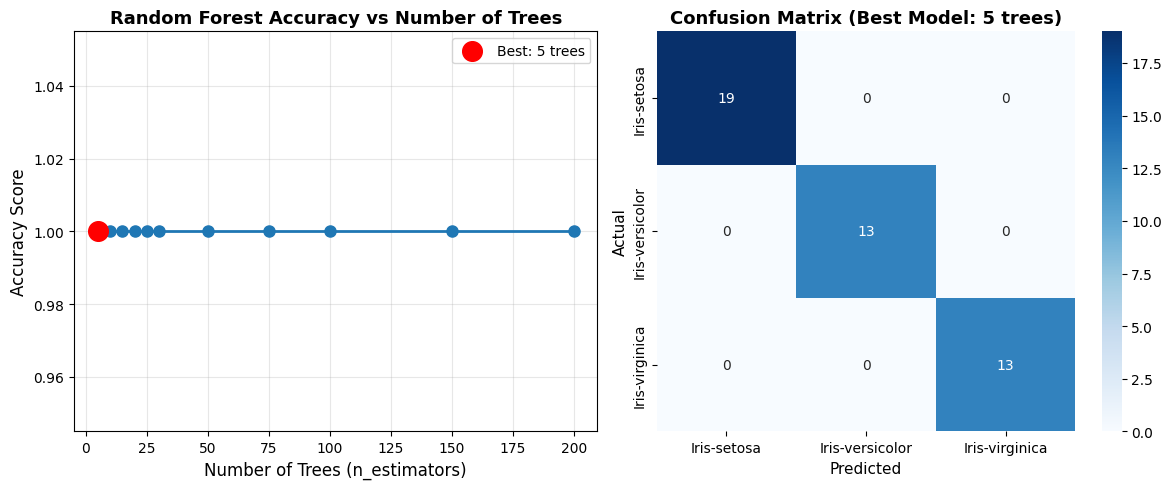


SUMMARY TO WRITE IN OBSERVATION BOOK

Best Accuracy Score: 1.0000 (100.00%)
Number of Trees (n_estimators): 5

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Comparison:
- Default model (10 trees) accuracy: 1.0000
- Best model (5 trees) accuracy: 1.0000
- Improvement: 0.00%



In [3]:
# Lab 7: Random Forest Ensemble Method
# Dataset: Iris Dataset
# Task: Implement Random Forest classifier and fine-tune n_estimators

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================================

# Load iris dataset
df = pd.read_csv('iris (2).csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except last (features)
y = df.iloc[:, -1]   # Last column (species - target)

print("\nFeatures:", X.columns.tolist())
print("Target classes:", y.unique())

# ============================================================================
# STEP 2: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ============================================================================
# STEP 3: BUILD RANDOM FOREST WITH DEFAULT n_estimators=10
# ============================================================================

print("\n" + "="*70)
print("PART A: DEFAULT RANDOM FOREST (n_estimators=10)")
print("="*70)

# Create RF classifier with default parameters
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)

# Train the model
rf_default.fit(X_train, y_train)

# Make predictions
y_pred_default = rf_default.predict(X_test)

# Calculate accuracy
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"\nAccuracy with 10 trees: {accuracy_default:.4f}")

# Confusion matrix
cm_default = confusion_matrix(y_test, y_pred_default)
print(f"\nConfusion Matrix:\n{cm_default}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))

# ============================================================================
# STEP 4: FINE-TUNE n_estimators TO FIND BEST ACCURACY
# ============================================================================

print("\n" + "="*70)
print("PART B: FINE-TUNING n_estimators")
print("="*70)

# Test different numbers of trees
n_estimators_list = [5, 10, 15, 20, 25, 30, 50, 75, 100, 150, 200]
accuracy_scores = []
best_accuracy = 0
best_n_estimators = 0
best_model = None
best_confusion_matrix = None

print("\nTesting different numbers of trees:")
print("-" * 50)
print(f"{'n_estimators':<15} {'Accuracy':<15}")
print("-" * 50)

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

    print(f"{n:<15} {accuracy:<15.4f}")

    # Track best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_n_estimators = n
        best_model = rf
        best_confusion_matrix = confusion_matrix(y_test, y_pred)

print("-" * 50)

# ============================================================================
# STEP 5: DISPLAY BEST RESULTS
# ============================================================================

print("\n" + "="*70)
print("BEST RESULTS")
print("="*70)

print(f"\nBest number of trees: {best_n_estimators}")
print(f"Best accuracy score: {best_accuracy:.4f}")
print(f"\nConfusion Matrix for best model:")
print(best_confusion_matrix)

# Get predictions from best model
y_pred_best = best_model.predict(X_test)
print("\nDetailed Classification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# Feature importance from best model
print("\nFeature Importance (from best model):")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance)

# ============================================================================
# STEP 6: VISUALIZATION
# ============================================================================

# Plot 1: Accuracy vs Number of Trees
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_estimators_list, accuracy_scores, marker='o', linewidth=2, markersize=8)
plt.scatter([best_n_estimators], [best_accuracy], color='red', s=200,
            label=f'Best: {best_n_estimators} trees', zorder=5)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Random Forest Accuracy vs Number of Trees', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Confusion Matrix Heatmap
plt.subplot(1, 2, 2)
sns.heatmap(best_confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(), yticklabels=y.unique(), cbar=True)
plt.title(f'Confusion Matrix (Best Model: {best_n_estimators} trees)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY FOR OBSERVATION BOOK
# ============================================================================

print("\n" + "="*70)
print("SUMMARY TO WRITE IN OBSERVATION BOOK")
print("="*70)
print(f"""
Best Accuracy Score: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)
Number of Trees (n_estimators): {best_n_estimators}

Confusion Matrix:
{best_confusion_matrix}

Comparison:
- Default model (10 trees) accuracy: {accuracy_default:.4f}
- Best model ({best_n_estimators} trees) accuracy: {best_accuracy:.4f}
- Improvement: {(best_accuracy - accuracy_default)*100:.2f}%
""")